# Opening-Range Breakout — does the first 5 minutes call the day? 📈
### The day-trading-TikTok staple, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

Every day-trading feed sells the same move: *"Mark the high and low of the first **5 minutes**. When price breaks **above** that range, go **long**. When it breaks **below**, go **short**. Hold to the close. The morning range tells you the day's direction."* It *feels* obviously right — the market 'chose a side', so ride it.

There's even real research behind a careful version (Zarattini & Grewal, 2023). So we tested it honestly. The punchline: on a real intraday tape the breakout doesn't beat a **coin** — a random entry that holds the same amount of time actually does **better**. This notebook shows why.

> 📓 **Plain-language layer.** Want the paired *t*-stats, the three random nulls, the cost sweep and the planted-signal control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Research & education. Every chart below is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opening_range_breakout import data, strategy as st

HAVE_REAL = data.have_real("QQQ")
DAYS = data.build_days("QQQ") if HAVE_REAL else None
print("real QQQ 5m cache present:", HAVE_REAL,
      "| sessions:", (0 if DAYS is None else len(DAYS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'sym': 'QQQ', 'days': 60, 'bars': 78, 'bh_bps': 15.5, 'up_days': 62, 'orb5_matched': [-1.3, 10.1, -11.3, -0.1, -1.32, 48, 0.992], 'orb5_coin': [-1.3, -0.1, -1.2, -0.1, -0.8, 48, 0.552], 'orb5_drift': [-1.3, 8.1, -9.4, -0.1, -0.86, 48, 0.976], 'orb15_matched': [-2.5, 9.7, -12.2, -0.2, -1.78, 45, 0.996], 'orb15_coin': [-2.5, -0.1, -2.3, -0.2, -1.18, 45, 0.601], 'orb15_drift': [-2.5, 7.9, -10.3, -0.2, -0.9, 45, 0.986], 'cost': [(0, -2.5, -12.2, -0.2), (1, -4.5, -14.2, -0.36), (2, -6.5, -16.2, -0.52), (3, -8.5, -18.2, -0.68), (5, -12.5, -22.2, -0.99)], 'breakeven': -6.1, 'syn': [(0.0, 4.1, 2.2, 2.0, 1.72, 0.088), (0.25, 8.3, 0.9, 7.4, 3.0, 0.0), (0.4, 11.8, -0.8, 12.6, 3.64, 0.0)], 'spy': [59, 1.5, -6.5, 0.18, -2.19]}


real QQQ 5m cache present: True | sessions: 60


## The answer first

| Question | Answer |
|---|---|
| Does breaking the morning range predict the day? | **No.** Across 60 real days the breakout trade made about **nothing** (-2.5 bps a day) — statistically a flat line. |
| But my backtest shows it makes money! | **That's the market drifting up, not the breakout.** In the same window the index rose most days; *any* mostly-long rule looks good. |
| So is it better than just… guessing? | **It's worse.** A **random** entry that holds the same amount of time made **+9.7 bps** a day — it *beat* the breakout ~99% of the time. |
| Do trading costs change the verdict? | **They only make it worse.** The rule is already behind a coin *before* costs, so there's no spread small enough to save it. |

> The morning range feels like information. On a real tape, it isn't — you'd have done better throwing a dart at the clock.

## 1 · The claim

> *"The first 5 minutes set the day's battle lines. Mark that high and low. The first **break above** the high → go long. The first **break below** the low → go short. Hold to the close and let the trend pay you."*

The serious version is a real paper — Zarattini & Grewal (2023), *Can Day Trading Really Be Profitable?* — a 5-minute ORB on QQQ with leverage and stops. We steelman the bare idea: **the first break of the opening range carries the day's direction.** Either that's true (and breaking the range beats entering at random), or the apparent profit is just the market's drift in disguise.

## 2 · So what?

If true, it would be a free daily edge anyone with a chart could harvest — and it would say something deep: that the opening auction *leaks* the day's direction. But there's a trap baked into how people test it. In a rising market, a rule that's **in the market most of the day** will print profits no matter *when* it enters. The only honest way to ask 'does the **range break** matter?' is to compare it to entering at a **random time** with the **same exposure**. If the breakout has real information, it must beat that coin.

## 3 · How would we even know?

We take **60 real trading days** of QQQ in 5-minute bars (that's all the free intraday history Yahoo gives — a short, mostly-up sample, and we say so). For each day:

1. **Run the rule.** Mark the first-5-minute (and first-15-minute) high/low; enter the bar *after* the first break, in the break's direction; hold to the close.
2. **Run the coin.** On the *same* day, enter at a **random** minute and hold to the same close — same amount of time in the market. Do it thousands of times.
3. **Compare.** If breaking the range is real, the rule beats the coin. If it doesn't, the 'edge' was the day's drift all along.

**What would make us say 'mirage':** the breakout failing to beat a same-exposure random entry. (Spoiler: it loses to it.)

## 4 · The teardown — let's actually look

**First: what does the breakout make vs a random entry of the same exposure?** Bars are average return per day, in basis points (1 bp = 0.01%).

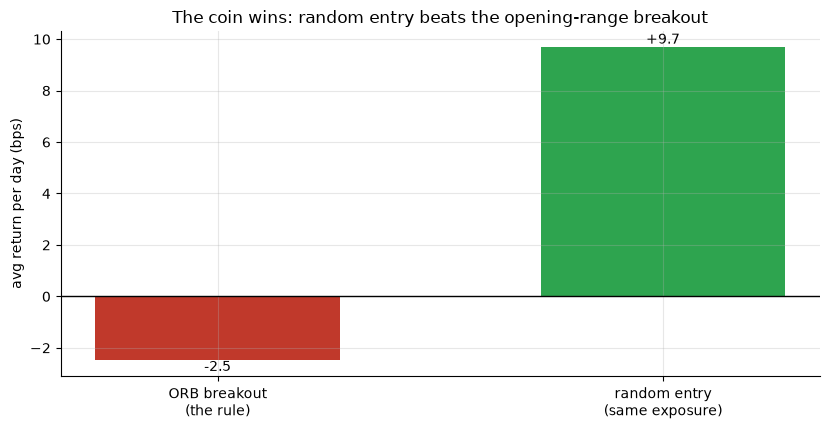

ORB breakout: -2.5 bps/day   random same-exposure entry: +9.7 bps/day


In [2]:
if HAVE_REAL:
    r15 = st.evaluate(DAYS, opening_range_min=15, cost_bps=0, null_mode='matched_dir', n_iter=1500)
    orb, nul = r15['orb_mean_bps'], r15['null_mean_bps']
else:
    orb, nul = R['orb15_matched'][0], R['orb15_matched'][1]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['ORB breakout\n(the rule)', 'random entry\n(same exposure)'], [orb, nul],
       color=[RED, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg return per day (bps)')
ax.set_title('The coin wins: random entry beats the opening-range breakout')
for i,v in enumerate([orb,nul]): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'ORB breakout: {orb:+.1f} bps/day   random same-exposure entry: {nul:+.1f} bps/day')

There it is. The breakout makes **-2.5 bps** a day — basically zero — while a **random** entry holding the same hours makes **+9.7 bps**. The dart *beats the rule*. Whatever profit a naive backtest showed was the market drifting up underneath both of them; only the random entry actually pocketed that drift, because the breakout often enters late and on the wrong side.

**Is it just bad luck in this sample?** No — the random entry beats the breakout on **~99%** of resamples, and it holds at both the 5-minute and 15-minute range, on a second ticker (SPY), and across every cost level. Here's the breakout's profit as we add realistic trading costs — it only sinks.

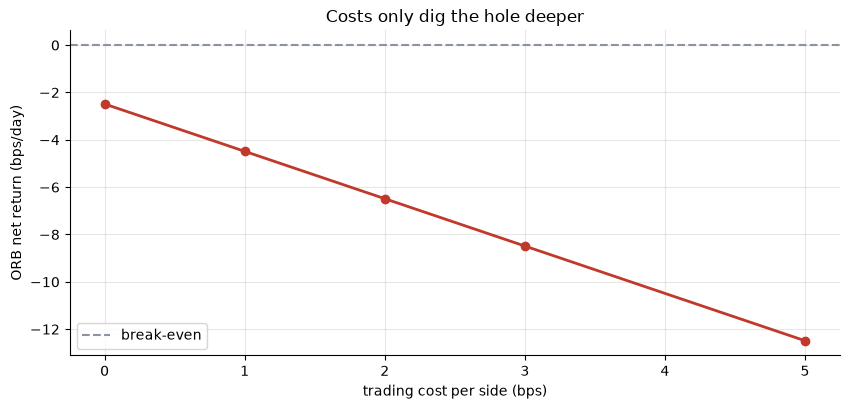

ORB net by cost (bps/day): ['-2.5', '-4.5', '-6.5', '-8.5', '-12.5']


In [3]:
costs = [c[0] for c in R['cost']]
if HAVE_REAL:
    nets = [st.evaluate(DAYS, 15, cost_bps=c, null_mode='matched_dir', n_iter=400)['orb_mean_bps'] for c in costs]
else:
    nets = [c[1] for c in R['cost']]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.plot(costs, nets, 'o-', c=RED, lw=2)
ax.axhline(0, ls='--', c=GREY, label='break-even')
ax.set_xlabel('trading cost per side (bps)'); ax.set_ylabel('ORB net return (bps/day)')
ax.set_title('Costs only dig the hole deeper'); ax.legend()
plt.tight_layout(); plt.show()
print('ORB net by cost (bps/day):', [f'{n:+.1f}' for n in nets])

The line starts below zero and walks downhill. Because the rule is already behind a coin *before* costs, there is no spread small enough to rescue it — the break-even cost is **negative** (~-6.1 bps). It was never a question of trimming fees.

## 5 · The verdict

- **Signal — None.** The breakout's daily return is a flat line (-2.5 bps, t ≈ 0) and it **loses** to a same-exposure random entry by ~12 bps/day. Breaking the morning range told us nothing the clock didn't.
- **Tradability — Mirage.** No cost level makes it win — it's behind a coin gross. Net of any realistic spread, it's a small, steady loser.
- **Beats a coin? — Busted.** The backtest profit was the market's drift; a random entry captured *more* of it. The 'edge' is an exposure illusion.

## 6 · Could you actually trade it? — proving the test isn't broken

Fair worry: maybe our measuring stick just *can't* find an opening-range edge. So we built a fake market where the breakout **must** work — prices that genuinely keep going the way they broke — and checked the test finds it. Then a fake market that's pure coin-flips, where it must find **nothing**.

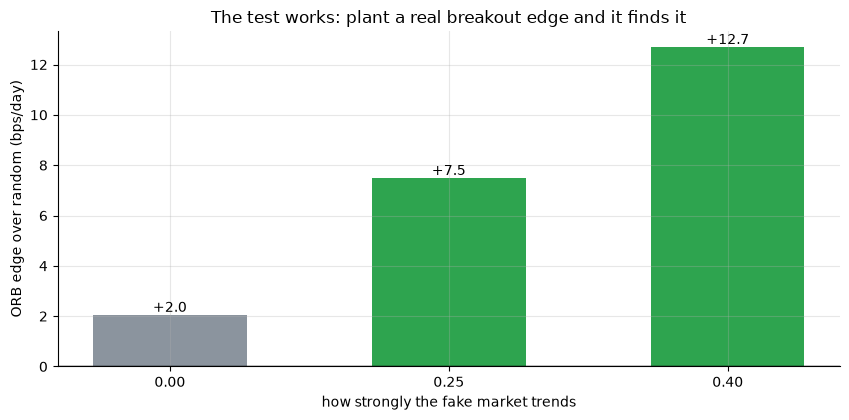

planted trend -> ['0.00', '0.25', '0.40']   edge found -> ['+2.0', '+7.5', '+12.7']


In [4]:
pers = [s[0] for s in R['syn']]
if HAVE_REAL or True:  # synthetic control runs anywhere
    edges = []
    for p in pers:
        S = data.synthetic_days(n_days=800, persistence=p, seed=352)
        edges.append(st.evaluate(S, 15, cost_bps=0, null_mode='matched_dir', n_iter=800)['edge_bps'])
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar([f'{p:.2f}' for p in pers], edges, color=[GREY, GREEN, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('how strongly the fake market trends')
ax.set_ylabel('ORB edge over random (bps/day)')
ax.set_title('The test works: plant a real breakout edge and it finds it')
for i,v in enumerate(edges): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('planted trend ->', [f'{p:.2f}' for p in pers], '  edge found ->', [f'{e:+.1f}' for e in edges])

When the fake market really does trend, the breakout beats the coin by a clear, growing margin — the test catches it. When the fake market is pure noise, the edge is ~0. So the **flat real-tape result is the market's verdict, not a broken ruler.** The opening range simply doesn't carry the day on real data.

## 7 · Going further 🚪

- **The serious steelman.** Zarattini & Grewal (2023) report a profitable ORB over *many years* with **leverage and ATR stops**. Our 60-day, no-stop, no-leverage test can't disprove that — but it shows the *bare* rule adds nothing over a coin here. Fork it and add the stop/target: does the edge appear, or is it the leverage?
- **Longer history.** Yahoo caps 5-minute data at ~60 days. Wire in a deeper intraday source and re-run across bull *and* bear regimes — the drift confound flips in a down-market.
- **The right cousin.** [Study 351](../../351-btc-5m-polymarket-momentum/) found a *real* intraday momentum signal that was simply priced in. Here the signal itself is missing — a cleaner 'no'.

*Think the 5-minute range has an edge a random entry can't match? Add the stop/target the pros use and show it beats the coin — the harness and the null are right here.*